Import Required Libraries

In [1]:
# ==========================================
# AppointmentBot AI
# Smart Appointment Assistant
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Create Dataset

In [2]:
data = {

'Message':[

'I want to book an appointment',
'Can I visit tomorrow?',
'Please schedule my appointment',
'Book a consultation',
'Reserve a slot',
'I need to meet the doctor',
'Can I book for Monday?',
'Schedule my visit',

'Thank you',
'Good Morning',
'Hello',
'Send me the report',
'Where is your clinic?',
'Nice service',
'What are your timings?',
'How much is the consultation fee?'

],

'Label':[

'Booking',
'Booking',
'Booking',
'Booking',
'Booking',
'Booking',
'Booking',
'Booking',

'Non-Booking',
'Non-Booking',
'Non-Booking',
'Non-Booking',
'Non-Booking',
'Non-Booking',
'Non-Booking',
'Non-Booking'

]

}

df = pd.DataFrame(data)

Display Dataset

In [3]:
df

,Message,Label
0,I want to book an appointment,Booking
1,Can I visit tomorrow?,Booking
2,Please schedule my appointment,Booking
3,Book a consultation,Booking
4,Reserve a slot,Booking
5,I need to meet the doctor,Booking
6,Can I book for Monday?,Booking
7,Schedule my visit,Booking
8,Thank you,Non-Booking
9,Good Morning,Non-Booking


Dataset Information

In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Message  16 non-null     object
 1   Label    16 non-null     object
dtypes: object(2)
memory usage: 388.0+ bytes


,0
Message,0
Label,0


Class Distribution

Check the number of Booking and Non-Booking messages.

In [5]:
df['Label'].value_counts()

,count
Label,
Booking,8
Non-Booking,8


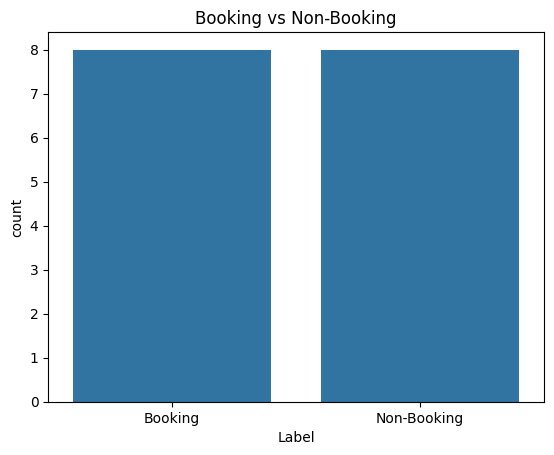

In [6]:
sns.countplot(data=df,x='Label')

plt.title("Booking vs Non-Booking")

plt.show()

Text Preprocessing

Clean the text by performing:

Lowercase conversion
Remove punctuation
Remove numbers
Remove stopwords
Apply stemming

In [7]:
stemmer = PorterStemmer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]',' ',text)

    words = text.split()

    words = [stemmer.stem(word)
             for word in words
             if word not in stopwords.words('english')]

    return " ".join(words)

Apply preprocessing

In [8]:
df['Clean_Text'] = df['Message'].apply(preprocess)

In [9]:
df

,Message,Label,Clean_Text
0,I want to book an appointment,Booking,want book appoint
1,Can I visit tomorrow?,Booking,visit tomorrow
2,Please schedule my appointment,Booking,pleas schedul appoint
3,Book a consultation,Booking,book consult
4,Reserve a slot,Booking,reserv slot
5,I need to meet the doctor,Booking,need meet doctor
6,Can I book for Monday?,Booking,book monday
7,Schedule my visit,Booking,schedul visit
8,Thank you,Non-Booking,thank
9,Good Morning,Non-Booking,good morn


Feature and Target

Separate the independent and dependent variables.

In [10]:
X = df['Clean_Text']

y = df['Label']

Train-Test Split

Split the dataset into training and testing sets.

In [11]:
X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.20,
random_state=42

)

CountVectorizer

Convert text into numerical features using CountVectorizer.

In [12]:
cv=CountVectorizer()

X_train_cv=cv.fit_transform(X_train)

X_test_cv=cv.transform(X_test)

Model 1

CountVectorizer + Naive Bayes

Train a Multinomial Naive Bayes model.

In [13]:
nb=MultinomialNB()

nb.fit(X_train_cv,y_train)

pred_nb=nb.predict(X_test_cv)

print("Accuracy :",accuracy_score(y_test,pred_nb))

Accuracy : 0.75


Classification Report

In [14]:
print(classification_report(y_test,pred_nb))

              precision    recall  f1-score   support

     Booking       1.00      0.67      0.80         3
 Non-Booking       0.50      1.00      0.67         1

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



Confusion Matrix

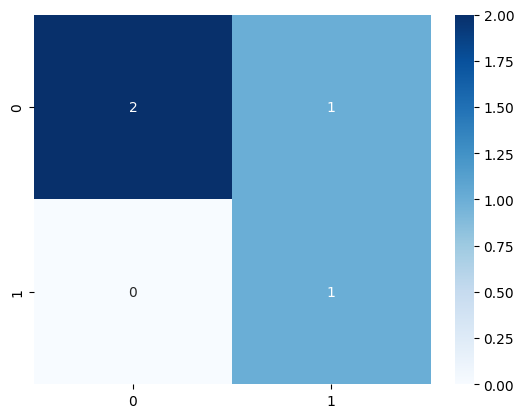

In [15]:
sns.heatmap(confusion_matrix(y_test,pred_nb),
annot=True,
fmt='d',
cmap='Blues')

plt.show()

CountVectorizer + Logistic Regression

In [16]:
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train_cv,y_train)

pred_lr=lr.predict(X_test_cv)

print("Accuracy :",accuracy_score(y_test,pred_lr))

Accuracy : 0.5


CountVectorizer + Linear SVM

In [17]:
svm=LinearSVC()

svm.fit(X_train_cv,y_train)

pred_svm=svm.predict(X_test_cv)

print("Accuracy :",accuracy_score(y_test,pred_svm))

Accuracy : 0.75


TF-IDF Vectorizer

Convert text into TF-IDF vectors.

In [18]:
tfidf=TfidfVectorizer()

X_train_tf=tfidf.fit_transform(X_train)

X_test_tf=tfidf.transform(X_test)

TF-IDF + Naive Bayes

In [19]:
model=MultinomialNB()

model.fit(X_train_tf,y_train)

pred=model.predict(X_test_tf)

print("Accuracy :",accuracy_score(y_test,pred))

Accuracy : 0.75


TF-IDF + Logistic Regression

In [20]:
model=LogisticRegression(max_iter=1000)

model.fit(X_train_tf,y_train)

pred=model.predict(X_test_tf)

print("Accuracy :",accuracy_score(y_test,pred))

Accuracy : 0.5


TF-IDF + Linear SVM

In [21]:
model=LinearSVC()

model.fit(X_train_tf,y_train)

pred=model.predict(X_test_tf)

print("Accuracy :",accuracy_score(y_test,pred))

Accuracy : 0.75


Compare Models


Compare the accuracy of all models to identify the best-performing one.

In [22]:
results=pd.DataFrame({

'Model':[

'CV + Naive Bayes',
'CV + Logistic Regression',
'CV + Linear SVM',

'TFIDF + Naive Bayes',
'TFIDF + Logistic Regression',
'TFIDF + Linear SVM'

],

'Accuracy':[

accuracy_score(y_test,pred_nb),
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_svm),

accuracy_score(y_test,MultinomialNB().fit(X_train_tf,y_train).predict(X_test_tf)),
accuracy_score(y_test,LogisticRegression(max_iter=1000).fit(X_train_tf,y_train).predict(X_test_tf)),
accuracy_score(y_test,LinearSVC().fit(X_train_tf,y_train).predict(X_test_tf))

]

})

results

,Model,Accuracy
0,CV + Naive Bayes,0.75
1,CV + Logistic Regression,0.50
2,CV + Linear SVM,0.75
3,TFIDF + Naive Bayes,0.75
4,TFIDF + Logistic Regression,0.50
5,TFIDF + Linear SVM,0.75


Best Model

Sort the models based on accuracy.

In [23]:
results.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy
0,CV + Naive Bayes,0.75
2,CV + Linear SVM,0.75
5,TFIDF + Linear SVM,0.75
3,TFIDF + Naive Bayes,0.75
1,CV + Logistic Regression,0.50
4,TFIDF + Logistic Regression,0.50


Predict New Message

Test the trained model with unseen customer messages.

In [24]:
message=["Can I book an appointment tomorrow?"]

message=[preprocess(i) for i in message]

message=tfidf.transform(message)

prediction=model.predict(message)

print(prediction[0])

Booking


Another Example

In [25]:
message=["Thank you for your service"]

message=[preprocess(i) for i in message]

message=tfidf.transform(message)

prediction=model.predict(message)

print(prediction[0])

Non-Booking
